# STARE

Source to Target Automatic Rotating Estimation (STARE) is a publicly available, blood-free quantification approach for PET tracers with irreversible kinetics. See the [preprint](https://biorxiv.org/content/10.1101/2021.09.15.460504v1.full) or [publication](https://doi.org/10.1016/j.neuroimage.2022.118901) for more details. This repository is the python implementation of it. This notebook is an example of its use.


In [1]:
""" Preliminaries, for developing and debugging in a python notebook.
    None of this is strictly necessary, but is useful for development.
"""

# Set up the path so our code is accessible w/o installing from pypi.
import sys, os
if os.path.abspath("..") not in sys.path:
    sys.path.insert(0, os.path.abspath(".."))

# Force automatic re-load of libraries on every call
# (useful for accelerated debugging of oft-changed library code)
%load_ext autoreload
%autoreload 2

print(f"Executing notebook from '{os.getcwd()}'")
print("System paths available:")
for p in sys.path:
    print(f"  {p}")

Executing notebook from '/home/mike/Projects/stare/stare_pet/examples'
System paths available:
  /home/mike/Projects/stare/stare_pet/examples
  /home/mike/Projects/stare/stare_pet
  /home/mike/Projects/stare/stare_pet/bin
  /home/mike/Projects/stare/stare_pet/starelib
  /usr/lib/python310.zip
  /usr/lib/python3.10
  /usr/lib/python3.10/lib-dynload
  
  /home/mike/.virtualenvs/stare/lib/python3.10/site-packages
  /home/mike/.virtualenvs/stare/lib/python3.10/site-packages/IPython/extensions
  /home/mike/.ipython


In [2]:
""" Inputs

    Specify the arguments we would be submitting to the command-line version of 'stare' if we were using it.
"""

from starelib import wrapper


# Input data for running in this notebook
local_arguments = [
    "NHFDG002",
    "--input-path", "/home/mike/Projects/stare/stare_data/sampleData",
    "--output-path", "/home/mike/Projects/stare/stare_data/test_python",
    "--axial-slices-to-clip", "6",
]

parser = wrapper.get_argument_parser()
args = parser.parse_args(local_arguments)
if wrapper.arguments_valid(args):
    print("Arguments are valid, OK to continue")
else:
    print("Fix the arguments before proceeding.")
print("Accepted arguments (after validation, including unspecified defaults)")
for k in vars(args):
    print(f"  {k}: {vars(args)[k]}")


regions: None
Arguments are valid, OK to continue
Accepted arguments (after validation, including unspecified defaults)
  subject: NHFDG002
  input_path: /home/mike/Projects/stare/stare_data/sampleData
  output_path: /home/mike/Projects/stare/stare_data/test_python/NHFDG002
  axial_slices_to_clip: 6
  pet_units: kBq
  pvc_method: STC
  fwhm: 5.9
  tracer: FDG
  vasc_corr_pct: 5
  ignore_frames: []
  regions: ['cerfullcs_c', 'cin', 'hip', 'par', 'pfc', 'pip']
  options_file: None
  verbose: 0


In this cell, we simply replicate the beginning of the 'stare' function in 'starelib/wrapper.py'

We could simply call it, but that would be the same as running the whole
multi-step process from the command line. This notebook allows us to run one step
at a time and preview outputs in a debugger before continuing.

In [4]:
import logging
from datetime import datetime
from starelib.wrapper import get_tacs, get_mid_times, get_images

# Validate out_path argument
begin_timestamp = datetime.now()
logging.info(f"Begin STARE.")

# Read data
tacs = get_tacs(args.input_path, args.subject)
mid_times = get_mid_times(args.input_path, args.subject, args.ignore_frames)
images = get_images(args.input_path, args.subject, args.ignore_frames)


The first step in STARE is vascular_clustering.

We just call the vascular_clustering function here. This allows for easy
setup of a debugger to drop in and inspect variables as it runs. It also
allows for in-notebook reporting of the results.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


made a palette of 29 gray values.
made a palette of 8 vascular best-in-k values.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


made a palette of 3 gray values.
made a palette of 1 vascular best-in-k values.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


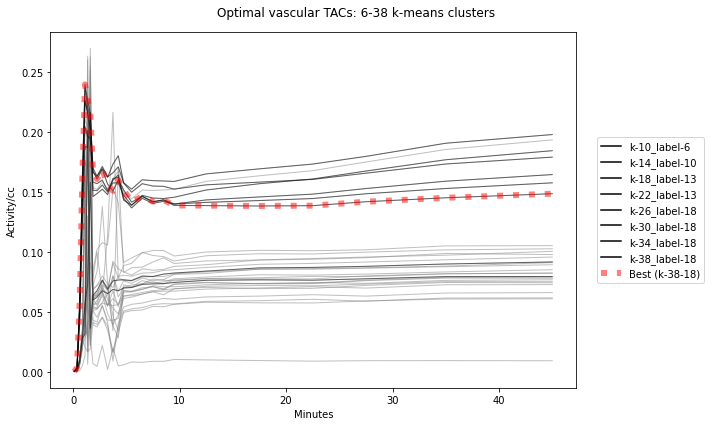

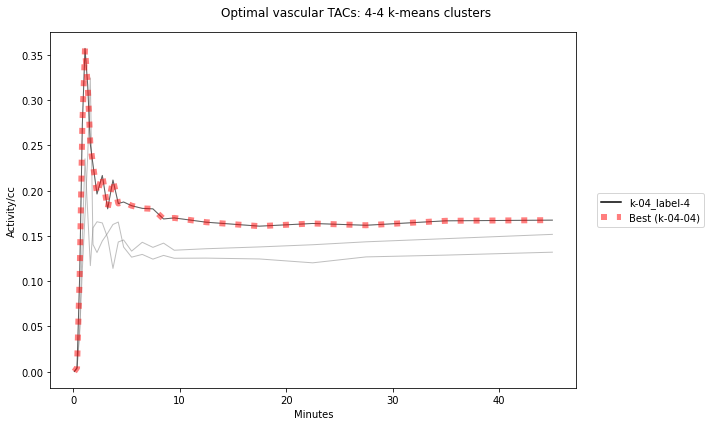

In [5]:
from starelib.wrapper import vascular_clustering

rslt1 = vascular_clustering(args.output_path, images,
                            pet_units=args.pet_units,
                            axial_slices_to_clip=args.axial_slices_to_clip,
                            mid_times=mid_times,
                            verbose=0)


## Equations

### 1

The standard 2 tissue irreversible compartment model (2TCirr) (manuscript eq 1)

$$C_T(t)=K_1({IRF}\otimes{C_p})=K_1[(\frac{k_2}{k_2+k_3}e^{-(k_2+k_3)t} + \frac{k_3}{k_2+k_3})\otimes{C_p}](t)$$

where $t$ is time

where ${IRF}$ is the impulse response function for the target region

where $k_1$, $k_2$, $k_3$ are the microparameters of the 2TCirr model for the target region


### 2

Using equation 1 for both "source" and "target" compartments.

$$C_T(t)=K_{1,T}({IRF}_T\otimes{C_p})=K_{1,T}[(\frac{k_{2,T}}{k_{2,T}+k_{3,T}}e^{-(k_{2,T}+k_{3,T})t} + \frac{k_{3,T}}{k_{2,T}+k_{3,T}})\otimes{C_p}](t)$$

$$C_S(t)=K_{1,S}({IRF}_S\otimes{C_p})=K_{1,S}[(\frac{k_{2,S}}{k_{2,S}+k_{3,S}}e^{-(k_{2,S}+k_{3,S})t} + \frac{k_{3,S}}{k_{2,S}+k_{3,S}})\otimes{C_p}](t)$$


### 3

Define the source-to-target tissue model using a LaPlace transform to express each target compartment's TAC

$$f_T(t,\theta_{T,S})=\frac{K_{1,T}}{K_{1,S}}C_s(t) + \frac{K_{1,T}}{K_{1,S}}C_s(t)\otimes(L_{T,S}e^{{v_{T,S}}^t}+M_{T,S}e^{{\epsilon_{T,S}}^t})$$

where t is time, $\otimes$ denotes convolution, and $\theta_{T,S}$ comprises the macro-parameters $L_{T,S}$, $M_{T,S}$, $v_{T,S}$, and $\epsilon_{T,S}$.


Just checking: $\sigma\epsilon\omega\pi$ $\Sigma\Omega\Pi$

### 4

Sum the square of the residuals to determine goodness of fit.

$$\phi(t_m,\theta_{T,S})=\sum_{T=1}^{n}\sum_{m=1}^{n}w_m(C_T(t_m)-f_T(t_m,\theta_{T,S}))^2$$

where $w$ represents a set of known weights for PET frame durations.


### 5

To equation 4, add a term anchoring the estimate to PET-derived measures of vascular activity.

$$\phi(t_m,\theta_{T,S})=\sum_{T=1}^{n}\sum_{m=1}^{n}w_m(C_T(t_m)-f_T(t_m,\theta_{T,S}))^2 + \lambda\sum_{T=1}^N\lvert{K_{i,T}-K_{i,vasc,T}}\rvert$$

This is the final cost function used to fit the model.


### Altogether

From the manuscript, Figure 1

![Manuscript Figure 1](bartlett_2021_stare_figure1.jpg "Figure 1")


In [2]:
from src.util import f

f("Working")


Working
